# UAV Model interpretation

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import copy
import torch.nn.functional as F

DATA_DIR = r"\data\input"
SPLIT_PATH = os.path.join(DATA_DIR, "UAV/uav_splits.json")

# =========================
# ⭐ Dataset selection
# =========================
selected_datasets = ["uav"]

DATASET_CONFIG = {
    "uav": (0, "UAV.csv"),
    "sentinel": (1, "Sentinel-2.csv"),
    "landsat": (2, "Landsat-8.csv"),
}

# =========================
# 0. Spectral normalization settings
# =========================
GLOBAL_LAMBDA_MIN = 350.0
GLOBAL_LAMBDA_MAX = 1002

def normalize_wavelength(x):
    return (x - GLOBAL_LAMBDA_MIN) / (GLOBAL_LAMBDA_MAX - GLOBAL_LAMBDA_MIN)

def normalize_delta(x):
    return (x - GLOBAL_LAMBDA_MIN) / (GLOBAL_LAMBDA_MAX - GLOBAL_LAMBDA_MIN)

# =========================
# ⭐ split loader
# =========================
def load_split(path, fold_id=0):
    with open(path, "r") as f:
        folds = json.load(f)

    split = folds[fold_id]
    return (
        np.array(split["train_idx"]),
        np.array(split["test_idx"])
    )

# =========================
# Dataset
# =========================
class SpectralDataset(Dataset):
    def __init__(self, file_path, dtype, x_mean, x_std):
        df = pd.read_csv(file_path, encoding='gbk')
        self.dtype = dtype

        temp = df.iloc[:, -2].values.astype(np.float32)
        self.x = df.iloc[:, :-2].values.astype(np.float32)
        self.y = df.iloc[:, -1].values.astype(np.float32)

        # NDWI filter
        if dtype == 1:
            ndwi = (df['B3'] - df['B8']) / (df['B3'] + df['B8'] + 1e-8)
            mask = ndwi > 0.1
            self.x, self.y, temp = self.x[mask], self.y[mask], temp[mask]

        elif dtype == 2:
            ndwi = (df['SR_B3'] - df['SR_B5']) / (df['SR_B3'] + df['SR_B5'] + 1e-8)
            mask = ndwi > 0.1
            self.x, self.y, temp = self.x[mask], self.y[mask], temp[mask]

        # clean
        mask = np.all(self.x >= 0, axis=1)
        self.x, self.y, temp = self.x[mask], self.y[mask], temp[mask]

        # global norm
        self.x = (self.x - x_mean) / (x_std + 1e-6)

        # wavelength
        if dtype == 0:
            self.lambda_ = np.arange(350, 1003, 4).astype(np.float32)
            self.delta = np.full_like(self.lambda_, 4.0)
            self.group_id = np.arange(len(self.x)) // 10

        elif dtype == 1:
            bands = [(443,20),(490,65),(560,35),(665,30),(705,15),(740,15),
                     (783,20),(842,115),(865,20),(945,20)]
            self.lambda_ = np.array([b[0] for b in bands], dtype=np.float32)
            self.delta = np.array([b[1] for b in bands], dtype=np.float32)

        else:
            bands = [(443,20),(482,65),(561,75),(655,50),(865,40)]
            self.lambda_ = np.array([b[0] for b in bands], dtype=np.float32)
            self.delta = np.array([b[1] for b in bands], dtype=np.float32)

        self.lambda_ = normalize_wavelength(self.lambda_)
        self.delta = normalize_delta(self.delta)

        self.temp = (temp - temp.mean()) / (temp.std() + 1e-6)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "x": torch.tensor(self.x[idx]),
            "lambda": torch.tensor(self.lambda_),
            "delta": torch.tensor(self.delta),
            "y": torch.tensor(self.y[idx]),
            "type": torch.tensor(self.dtype),
            "temp": torch.tensor(self.temp[idx])
        }

# =========================
# Model
# =========================
class SpectralFusionModel(nn.Module):
    def __init__(self, d_model=64, grid_size=64):
        super().__init__()

        self.d_model = d_model

        # =========================
        # 1. Fixed spectral grid
        # =========================
        self.register_buffer(
            "grid",
            torch.linspace(0, 1, grid_size)
        )

        # =========================
        # 2. Fourier Encoding
        # =========================
        self.fourier_B = nn.Parameter(
            torch.logspace(0, 2, d_model // 2)
        )
        self.fourier_scale = nn.Parameter(torch.ones(1))

        # fusion layer for concatenated features
        self.fusion = nn.Linear(d_model * 2, d_model)

        # =========================
        # 3. Input embedding
        # =========================
        self.input_embed = nn.Sequential(
            nn.Linear(3, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

        self.temp_embed = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

        # =========================
        # 4. Learnable spectral diffusion weights
        # =========================
        self.spectral_weight_net = nn.Sequential(
            nn.Linear(4, 32),
            nn.GELU(),
            nn.Linear(32, 16),
            nn.GELU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

        # =========================
        # 5. FiLM conditioning
        # =========================
        self.film = nn.Sequential(
            nn.Linear(4, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, d_model * 2)
        )

        # =========================
        # 5. Transformer Encoder
        # =========================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.LayerNorm(d_model)
        )

        # =========================
        # 7. Regression head
        # =========================
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    # =========================
    # Fourier Encoding
    # =========================
    def fourier_encoding(self, x):
        x = x.unsqueeze(-1)  # (B, N, 1)

        proj = x * self.fourier_B * self.fourier_scale

        return torch.cat([
            torch.sin(proj),
            torch.cos(proj)
        ], dim=-1)

    # =========================
    # spectral projection
    # =========================
    def spectral_project(self, z, wl, delta):

        grid = self.grid.to(z.device).unsqueeze(0).unsqueeze(0)

        wl = wl.unsqueeze(-1)
        delta = delta.unsqueeze(-1)

        sigma = delta + 1e-6

        weight = torch.exp(-((wl - grid) ** 2) / (sigma ** 2))
        weight = weight / (weight.sum(dim=1, keepdim=True) + 1e-8)

        return (z.unsqueeze(2) * weight.unsqueeze(-1)).sum(dim=1)

    # =========================
    # forward
    # =========================
    def forward(self, x, wl, delta, dtype, temp):

        # -------------------------
        # 1. input embedding
        # -------------------------
        x = x.unsqueeze(-1)
        wl = wl.unsqueeze(-1)
        delta = delta.unsqueeze(-1)

        inp = torch.cat([x, wl, delta], dim=-1)
        z = self.input_embed(inp)

        # # -------------------------
        # # 2. FiLM conditioning
        # # -------------------------
        # cond = torch.stack([
        #     dtype.float(),
        #     temp,
        #     wl.mean(dim=1).squeeze(-1),
        #     delta.mean(dim=1).squeeze(-1)
        # ], dim=1)

        # gamma, beta = self.film(cond).chunk(2, dim=1)
        # z = gamma.unsqueeze(1) * z + beta.unsqueeze(1)

        # -------------------------
        # 3. spectral projection
        # -------------------------
        z = self.spectral_project(
            z,
            wl.squeeze(-1),
            delta.squeeze(-1)
        )

        # -------------------------
        # 4. Fourier positional encoding
        # -------------------------
        grid = self.grid.unsqueeze(0).expand(z.size(0), -1)

        pos = self.fourier_encoding(grid)

        z = torch.cat([z, pos], dim=-1)
        z = self.fusion(z)

        # -------------------------
        # 5. Transformer + CLS token pooling
        # -------------------------
        B = z.size(0)
        t = self.temp_embed(temp.unsqueeze(-1)).unsqueeze(1)
        cls = self.cls_token.expand(B, -1, -1)  # (B,1,d)
        z = torch.cat([t,  z], dim=1)          # (B,N+1,d)

        z = self.encoder(z)

        z = z[:, 0]  # ⭐ CLS token output

        # -------------------------
        # 6. regression head
        # -------------------------
        return self.head(z).squeeze()

# =========================
# Loss
# =========================
def r2_aware_loss(pred, target):
    mse = torch.mean((pred - target) ** 2)

    pred_c = pred - pred.mean()
    tgt_c = target - target.mean()

    corr = torch.sum(pred_c * tgt_c) / (
        torch.sqrt(torch.sum(pred_c ** 2)) *
        torch.sqrt(torch.sum(tgt_c ** 2)) + 1e-8
    )

    return mse + 0.5 * (1 - corr)

# =========================
# ⭐ evaluation
# =========================
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            pred = model(
                batch["x"].to(device),
                batch["lambda"].to(device),
                batch["delta"].to(device),
                batch["type"].to(device),
                batch["temp"].to(device)
            )

            y_true.extend(batch["y"].cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import copy
import torch.nn.functional as F

DATA_DIR = r"\data\input"
SPLIT_PATH = os.path.join(DATA_DIR, "UAV/uav_splits.json")
model_save_dir = os.path.join(DATA_DIR, "UAV/CSF-PFE")
os.makedirs(model_save_dir, exist_ok=True)
explain_save_dir = os.path.join(DATA_DIR, "explain")
os.makedirs(explain_save_dir, exist_ok=True)

def denormalize_wavelength(x):
    return (
        x * (GLOBAL_LAMBDA_MAX - GLOBAL_LAMBDA_MIN)
        + GLOBAL_LAMBDA_MIN
    )
def explain_fold(model, dataset, device, fold_id, save_dir=None):

    model.eval()

    # ----------------------------
    # Gaussian centers (spectral positions)
    # ----------------------------
    centers = np.linspace(350, 1002, 65)  
    sigmas = [2.5, 5, 10, 20, 40, 80, 160]

    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    wl_real = denormalize_wavelength(dataset.lambda_)

    # baseline = dataset mean spectrum
    baseline = torch.tensor(dataset.x.mean(axis=0), dtype=torch.float32).to(device)

    results = {
    sigma: {
        "mean_abs": [],
        "positive_ratio": [],
        "negative_ratio": [],
        "std": [],
    }
    for sigma in sigmas
}

    for sigma in sigmas:
        print(f"\n=== Fold {fold_id} | Sigma = {sigma} nm ===")

        for c in centers:
            all_diff = []
            all_sign = []

            # Gaussian weight
            weight = np.exp(-((wl_real - c) ** 2) / (2 * sigma ** 2))
            weight = weight / (weight.max() + 1e-8)
            weight = torch.tensor(weight, dtype=torch.float32).to(device)

            for batch in loader:
                x = batch["x"].to(device)
                wl = batch["lambda"].to(device)
                delta = batch["delta"].to(device)
                dtype = batch["type"].to(device)
                temp = batch["temp"].to(device)

                with torch.no_grad():
                    pred0 = model(x, wl, delta, dtype, temp)

                # Occlusion
                w = weight.unsqueeze(0).expand_as(x)
                baseline_expand = baseline.unsqueeze(0).expand_as(x)
                x_new = x * (1 - w) + baseline_expand * w

                with torch.no_grad():
                    pred1 = model(x_new, wl, delta, dtype, temp)

                diff = (pred1 - pred0).cpu().numpy().reshape(-1)

                # x_new - x
                dx = (x_new - x).cpu().numpy()

                # Average perturbation direction per sample (a scalar)
                dx_mean = dx.mean(axis=1)

                # -------------------------
                # Contribution direction (stable interpretation)
                # -------------------------
                # positive: perturbation increases prediction
                # negative: perturbation decreases prediction
                effect_sign = np.sign(diff * dx_mean)

                all_diff.extend(diff)
                all_sign.extend(effect_sign)

            all_diff = np.asarray(all_diff)
            all_sign = np.asarray(all_sign)

            positive_ratio = np.mean(all_sign > 0)
            negative_ratio = np.mean(all_sign < 0)

            results[sigma]["mean_abs"].append(np.mean(np.abs(all_diff)))
            results[sigma]["positive_ratio"].append(positive_ratio)
            results[sigma]["negative_ratio"].append(negative_ratio)
            results[sigma]["std"].append(np.std(all_diff))

        print(f"Fold {fold_id} | Sigma {sigma} done.")

    # ----------------------------
    # save results
    # ----------------------------
    if save_dir is None:
        save_dir = DATA_DIR

    for metric in [
        "mean_abs",
        "positive_ratio",
        "negative_ratio",
        "std",
    ]:
        save_path = os.path.join(save_dir, f"importance_{metric}_fold{fold_id}.npy")
        np.save(save_path, {k: v[metric] for k, v in results.items()})

    np.save(os.path.join(save_dir, f"centers_fold{fold_id}.npy"), centers)
    print(f"✅ Fold {fold_id} explanation saved.")
    

device = "cuda" if torch.cuda.is_available() else "cpu"

paths = [
    (DATASET_CONFIG[name][0],
        os.path.join(DATA_DIR, DATASET_CONFIG[name][1]))
    for name in selected_datasets
]

# =========================
# global normalization
# =========================
all_x = []
for _, path in paths:
    df = pd.read_csv(path, encoding='gbk')
    all_x.append(df.iloc[:, :-2].values.astype(np.float32))

all_x = np.vstack(all_x)
x_mean = all_x.mean(axis=0)
x_std = all_x.std(axis=0) + 1e-6

dataset = SpectralDataset(paths[0][1], paths[0][0], x_mean, x_std)


for fold_id in range(5):
    model_path = os.path.join(model_save_dir, f"best_model_fold{fold_id}.pth")
    model = SpectralFusionModel().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    explain_fold(model, dataset, device, fold_id, save_dir=explain_save_dir)

C:\Users\PC\AppData\Local\Temp\ipykernel_30248\2869048854.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev


=== Fold 0 | Sigma = 2.5 nm ===
Fold 0 | Sigma 2.5 done.

=== Fold 0 | Sigma = 5 nm ===
Fold 0 | Sigma 5 done.

=== Fold 0 | Sigma = 10 nm ===
Fold 0 | Sigma 10 done.

=== Fold 0 | Sigma = 20 nm ===
Fold 0 | Sigma 20 done.

=== Fold 0 | Sigma = 40 nm ===
Fold 0 | Sigma 40 done.

=== Fold 0 | Sigma = 80 nm ===
Fold 0 | Sigma 80 done.

=== Fold 0 | Sigma = 160 nm ===
Fold 0 | Sigma 160 done.
✅ Fold 0 explanation saved.

=== Fold 1 | Sigma = 2.5 nm ===
Fold 1 | Sigma 2.5 done.

=== Fold 1 | Sigma = 5 nm ===
Fold 1 | Sigma 5 done.

=== Fold 1 | Sigma = 10 nm ===
Fold 1 | Sigma 10 done.

=== Fold 1 | Sigma = 20 nm ===
Fold 1 | Sigma 20 done.

=== Fold 1 | Sigma = 40 nm ===
Fold 1 | Sigma 40 done.

=== Fold 1 | Sigma = 80 nm ===
Fold 1 | Sigma 80 done.

=== Fold 1 | Sigma = 160 nm ===
Fold 1 | Sigma 160 done.
✅ Fold 1 explanation saved.

=== Fold 2 | Sigma = 2.5 nm ===
Fold 2 | Sigma 2.5 done.

=== Fold 2 | Sigma = 5 nm ===
Fold 2 | Sigma 5 done.

=== Fold 2 | Sigma = 10 nm ===
Fold 2 | Sig

## fig

C:\Users\PC\AppData\Local\Temp\ipykernel_30248\1897356273.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab10', len(selected_sigmas))


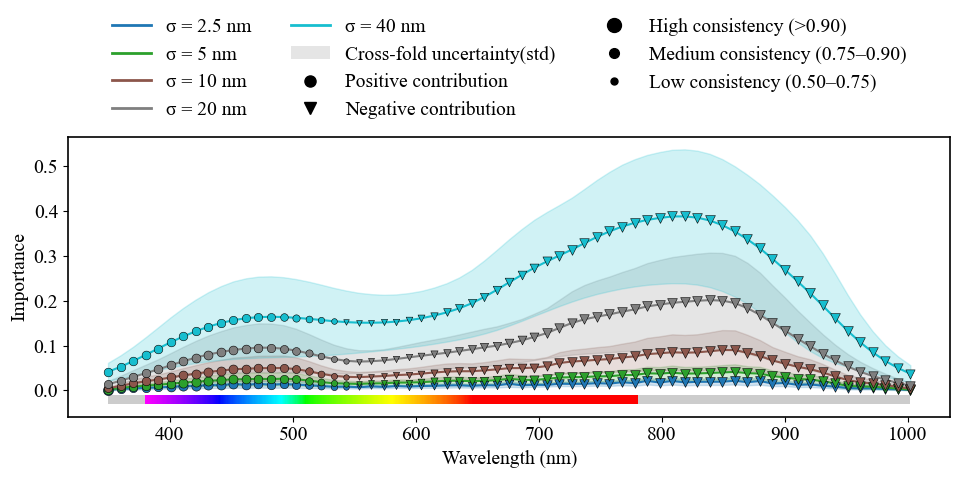

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# =========================
# ⭐ global font settings
# =========================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
DATA_DIR = r"E:\LYQ\work\250916remote_model\data\input"
SPLIT_PATH = os.path.join(DATA_DIR, "UAV/uav_splits.json")

explain_save_dir = os.path.join(DATA_DIR, "explain")

#=========================
# 1. read all folds
#=========================
all_mean_abs = []
all_positive = []
all_negative = []

for fold in range(5):
    centers = np.load(os.path.join(explain_save_dir, f"centers_fold{fold}.npy"))
    mean_abs = np.load(
        os.path.join(explain_save_dir, f"importance_mean_abs_fold{fold}.npy"),
        allow_pickle=True
    ).item()

    positive = np.load(
        os.path.join(
            explain_save_dir,
            f"importance_positive_ratio_fold{fold}.npy"
        ),
        allow_pickle=True
    ).item()

    negative = np.load(
        os.path.join(
            explain_save_dir,
            f"importance_negative_ratio_fold{fold}.npy"
        ),
        allow_pickle=True
    ).item()

    all_mean_abs.append(mean_abs)
    all_positive.append(positive)
    all_negative.append(negative)

#=========================
# 2. calculate mean and std
#=========================
# sigmas = [2.5, 5, 10, 20, 40, 80, 160]
selected_sigmas = [2.5, 5, 10, 20, 40]

mean_abs_final = {}
std_fold_final = {}
positive_final = {}
negative_final = {}

for sigma in selected_sigmas:

    fold_abs = []
    fold_positive = []
    fold_negative = []

    for fold in range(5):

        fold_abs.append(
            np.array(
                all_mean_abs[fold][sigma]
            )
        )

        fold_positive.append(
            np.array(all_positive[fold][sigma])
        )

        fold_negative.append(
            np.array(all_negative[fold][sigma])
        )

    fold_abs = np.array(fold_abs)
    fold_positive = np.array(fold_positive)
    fold_negative = np.array(fold_negative)

    mean_abs_final[sigma] = fold_abs.mean(axis=0)

    std_fold_final[sigma] = fold_abs.std(axis=0)

    positive_final[sigma] = fold_positive.mean(axis=0)
    negative_final[sigma] = fold_negative.mean(axis=0)

fig, ax = plt.subplots(figsize=(10,5))

# white background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# =========================
# ⭐ auto colors
# =========================
import matplotlib.cm as cm
colors_map = cm.get_cmap('tab10', len(selected_sigmas))

sigma_colors = {
    sigma: colors_map(i)
    for i, sigma in enumerate(selected_sigmas)
}

# =========================
# main plot
# =========================
for sigma in selected_sigmas:

    y = np.array(mean_abs_final[sigma])
    y_std = np.array(std_fold_final[sigma])
    positive_ratio = np.array(positive_final[sigma])
    negative_ratio = np.array(negative_final[sigma])

    color = sigma_colors[sigma]

    # curve
    ax.plot(centers, y, color=color)

    # 2 sides uncertainty
    ax.fill_between(
        centers,
        y - y_std,
        y + y_std,
        color=color,
        alpha=0.2
    )

    # marker
    MIN_SIZE = 15
    MAX_SIZE = 90

    for i in range(len(centers)):

        if positive_ratio[i] >= negative_ratio[i]:

            # positive distribution
            consistency = positive_ratio[i]

            size = MIN_SIZE + (MAX_SIZE - MIN_SIZE) * (
                (consistency - 0.5) / 0.5
            )
            size = np.clip(size, MIN_SIZE, MAX_SIZE)

            ax.scatter(
                centers[i],
                y[i],
                marker='o',
                s=size,
                color=color,
                edgecolors='black',
                linewidths=0.4,
                zorder=5
            )

        else:

            # negative distribution
            consistency = negative_ratio[i]

            size = MIN_SIZE + (MAX_SIZE - MIN_SIZE) * (
                (consistency - 0.5) / 0.5
            )
            size = np.clip(size, MIN_SIZE, MAX_SIZE)

            ax.scatter(
                centers[i],
                y[i],
                marker='v',
                s=size,
                color=color,
                edgecolors='black',
                linewidths=0.4,
                zorder=5
            )

# =========================
# ⭐ legend
# =========================
legend_elements = []

# σ curves
for sigma in selected_sigmas:
    legend_elements.append(
        Line2D([0], [0], color=sigma_colors[sigma], lw=2, label=f'σ = {sigma} nm')
    )

# std 
legend_elements.append(
    Patch(facecolor='gray', alpha=0.2, label='Cross-fold uncertainty(std)')
)

# positive and negative contributions
legend_elements += [
    Line2D(
        [0], [0],
        marker='o',
        color='black',
        linestyle='None',
        markersize=8,
        label='Positive contribution'
    ),

    Line2D(
        [0], [0],
        marker='v',
        color='black',
        linestyle='None',
        markersize=8,
        label='Negative contribution'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='black',
        linestyle='None',
        markersize=10,
        label='High consistency (>0.90)'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='black',
        linestyle='None',
        markersize=7,
        label='Medium consistency (0.75–0.90)'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='black',
        linestyle='None',
        markersize=5,
        label='Low consistency (0.50–0.75)'
    ),
]
ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,   # ⭐ 每行 3 个
    frameon=False
)

# =========================
# axes labels
# =========================
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Importance")

ax.grid(False)

# =========================
# 4. spectral color band
# =========================
# =========================
# 1. wavelength to RGB function
# =========================
def wavelength_to_rgb(wavelength):
    gamma = 0.8
    if wavelength < 380 or wavelength > 780:
        return (0.7, 0.7, 0.7)
    
    if wavelength < 440:
        r = -(wavelength - 440) / (440 - 380)
        g = 0.0
        b = 1.0
    elif wavelength < 490:
        r = 0.0
        g = (wavelength - 440) / (490 - 440)
        b = 1.0
    elif wavelength < 510:
        r = 0.0
        g = 1.0
        b = -(wavelength - 510) / (510 - 490)
    elif wavelength < 580:
        r = (wavelength - 510) / (580 - 510)
        g = 1.0
        b = 0.0
    elif wavelength < 645:
        r = 1.0
        g = -(wavelength - 645) / (645 - 580)
        b = 0.0
    else:
        r = 1.0
        g = 0.0
        b = 0.0

    return (r**0.8, g**0.8, b**0.8)
band_y = -0.03   
band_h = 0.02    

wavelengths = np.linspace(350, 1002, 652)

for i in range(len(wavelengths) - 1):
    wl = wavelengths[i]
    wl_next = wavelengths[i+1]

    # Determine color based on wavelength
    if 380 <= wl <= 780:
        color = wavelength_to_rgb(wl)
    else:
        color = (0.8, 0.8, 0.8)

    ax.add_patch(plt.Rectangle(
        (wl, band_y),
        wl_next - wl,
        band_h,
        color=color,
        linewidth=0
    ))

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

# ⭐ save
plt.savefig(
    "spectral_importance.png",
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

In [15]:
print(all_positive)
print(all_negative)
print("=" * 60)
print("Local maxima of mean importance")
print("=" * 60)
#=========================
# 2. 计算平均和 std
#=========================
# sigmas = [2.5, 5, 10, 20, 40, 80, 160]
selected_sigmas = [10, 20, 40]
for sigma in selected_sigmas:

    y = np.array(mean_abs_final[sigma])

    # 找局部极大值
    peaks = np.where((y[1:-1] > y[:-2]) &
                     (y[1:-1] > y[2:]))[0] + 1

    print(f"\nσ = {sigma} nm")
    print(f"Found {len(peaks)} local maxima")

    for idx in peaks:
        print(f"  {centers[idx]:7.2f} nm   importance = {y[idx]:.6f}")

[{2.5: [np.float64(0.743859649122807), np.float64(0.7666666666666667), np.float64(0.775438596491228), np.float64(0.7736842105263158), np.float64(0.7614035087719299), np.float64(0.7719298245614035), np.float64(0.7719298245614035), np.float64(0.7771929824561403), np.float64(0.7719298245614035), np.float64(0.7701754385964912), np.float64(0.7701754385964912), np.float64(0.7614035087719299), np.float64(0.7578947368421053), np.float64(0.756140350877193), np.float64(0.7473684210526316), np.float64(0.7403508771929824), np.float64(0.7315789473684211), np.float64(0.7263157894736842), np.float64(0.6964912280701754), np.float64(0.6807017543859649), np.float64(0.6684210526315789), np.float64(0.6631578947368421), np.float64(0.6456140350877193), np.float64(0.6456140350877193), np.float64(0.6350877192982456), np.float64(0.6), np.float64(0.5526315789473685), np.float64(0.5070175438596491), np.float64(0.47368421052631576), np.float64(0.4543859649122807), np.float64(0.43157894736842106), np.float64(0.433